# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/satyamgupta04/week1/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

### Selected method: Logistic Regression

I will use Logistic Regression as the first ML model for this lane.

The task is to prioritize content pages for human review based on observable search, content, and engagement signals. Logistic Regression is appropriate because it provides a simple and interpretable binary classification model that can produce a probability of the target outcome.

I am starting with Logistic Regression rather than a more complex model because the goal is to determine whether machine learning provides a meaningful improvement over the Week-4 rule-based baseline. A more complex model is only justified if it provides useful improvement on the same evaluation data.

The model will use only information available before the prediction window. Future-window information and label-derived fields will be excluded to avoid leakage.

The model will be compared against the Week-4 baseline using the same evaluation rows and the same evaluation metrics.

In [70]:
MODEL_NAME = "Logistic Regression"

print("Selected model:", MODEL_NAME)
print("Purpose: compare an interpretable ML model against the Week-4 baseline.")
print("Leakage rule: only information available before the prediction window may be used.")

Selected model: Logistic Regression
Purpose: compare an interpretable ML model against the Week-4 baseline.
Leakage rule: only information available before the prediction window may be used.


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

The dataset `model_data` is inherently time-aware, as it combines March 2026 data for features and April 2026 data for outcomes. This design helps prevent future leakage. For model training and evaluation, we will perform a stratified train-test split on this combined dataset. Stratification ensures that the proportion of the target variable (`decline_label`) is maintained in both the training and test sets.

We will exclude identifiers like `client_hash_id` and `content_hash_id`, and outcome-related columns from April, ensuring only March data and static content metadata are used as features. Missing values will be imputed, and categorical features will be one-hot encoded.

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define target and features
TARGET = 'decline_label'

y = model_data[TARGET]

# Features to exclude
EXCLUDE_FEATURES = [
    'client_hash_id',
    'content_hash_id',
    'decline_label',
    'april_impressions',
    'april_clicks',
    'april_sessions',
    'content_created_date',
    'content_updated_date'
]

X = model_data.drop(columns=EXCLUDE_FEATURES)

# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=['number', 'bool']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print(f"Numerical Features: {numerical_features}")
print(f"Categorical Features: {categorical_features}")
print(f"Target variable: {TARGET}")

Numerical Features: ['march_impressions', 'march_clicks', 'march_avg_position', 'march_sessions', 'march_engaged_sessions', 'gsc_available', 'ga4_available', 'search_volume', 'competition', 'cpc', 'backlinks', 'category_count', 'char_count', 'word_count', 'staleness_days', 'content_age_days']
Categorical Features: ['content_type', 'competition_level', 'main_intent', 'provider_used', 'model_used']
Target variable: decline_label


In [72]:
# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

X_train shape: (232005, 21)
X_test shape: (99431, 21)
y_train shape: (232005,)
y_test shape: (99431,)

Training target distribution:
decline_label
0    0.71639
1    0.28361
Name: proportion, dtype: float64

Test target distribution:
decline_label
0    0.716386
1    0.283614
Name: proportion, dtype: float64


In [73]:
from huggingface_hub import hf_hub_download

april_file = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="fact_content_daily_performance/month=2026-04/data_0.parquet",
    repo_type="dataset"
)

print("April file downloaded successfully.")
print(april_file)

April file downloaded successfully.
/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_daily_performance/month=2026-04/data_0.parquet


In [74]:
import os
import duckdb
import pandas as pd

# Connect DuckDB
con = duckdb.connect()

# Hugging Face cached files
march_file = "/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_daily_performance/month=2026-03/data_0.parquet"

# Find April file automatically from the same Hugging Face cache
snapshot_root = os.path.dirname(os.path.dirname(os.path.dirname(march_file)))

april_matches = []
for root, dirs, files in os.walk(snapshot_root):
    for file in files:
        if file == "data_0.parquet" and "month=2026-04" in root:
            april_matches.append(os.path.join(root, file))

if not april_matches:
    raise FileNotFoundError("April 2026 parquet file was not found.")

april_file = april_matches[0]

print("March file found:", os.path.exists(march_file))
print("April file found:", os.path.exists(april_file))
print("April file:", april_file)

March file found: True
April file found: True
April file: /root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_daily_performance/month=2026-04/data_0.parquet


In [75]:
march_file = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="fact_content_daily_performance/month=2026-03/data_0.parquet",
    repo_type="dataset"
)

print("March file downloaded successfully.")
print(march_file)

March file downloaded successfully.
/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_daily_performance/month=2026-03/data_0.parquet


In [76]:
print("March rows:")
print(con.execute(f"""
    SELECT COUNT(*) AS rows,
           MIN(report_date) AS min_date,
           MAX(report_date) AS max_date
    FROM read_parquet('{march_file}')
""").fetchdf())

print("\nApril rows:")
print(con.execute(f"""
    SELECT COUNT(*) AS rows,
           MIN(report_date) AS min_date,
           MAX(report_date) AS max_date
    FROM read_parquet('{april_file}')
""").fetchdf())

March rows:
      rows   min_date   max_date
0  9841378 2026-03-01 2026-03-31

April rows:
       rows   min_date   max_date
0  10424730 2026-04-01 2026-04-30


In [77]:
march_features = con.execute(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS march_impressions,
        SUM(gsc_clicks) AS march_clicks,
        AVG(gsc_avg_position) AS march_avg_position,
        SUM(ga4_sessions) AS march_sessions,
        SUM(ga4_engaged_sessions) AS march_engaged_sessions,
        MAX(gsc_data_available) AS gsc_available,
        MAX(ga4_data_available) AS ga4_available
    FROM read_parquet('{march_file}')
    GROUP BY
        client_hash_id,
        content_hash_id
""").fetchdf()

print("March feature rows:", len(march_features))
print("March feature columns:", list(march_features.columns))

march_features.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

March feature rows: 331437
March feature columns: ['client_hash_id', 'content_hash_id', 'march_impressions', 'march_clicks', 'march_avg_position', 'march_sessions', 'march_engaged_sessions', 'gsc_available', 'ga4_available']


,client_hash_id,content_hash_id,march_impressions,march_clicks,march_avg_position,march_sessions,march_engaged_sessions,gsc_available,ga4_available
0,client_62f4a7e64f5e0096,content_39d7361b4945d504,77.0,0.0,4.074107,NaN,NaN,True,<NA>
1,client_62f4a7e64f5e0096,content_cec711b02f3bbde6,602.0,4.0,4.428747,NaN,NaN,True,<NA>
2,client_62f4a7e64f5e0096,content_275b6f7f733016d4,810.0,1.0,4.866123,NaN,NaN,True,<NA>
3,client_62f4a7e64f5e0096,content_ceaec531566ffcfc,82.0,0.0,8.978086,NaN,NaN,True,<NA>
4,client_62f4a7e64f5e0096,content_755d951187fcd70a,1858.0,6.0,1.854929,NaN,NaN,True,<NA>


In [78]:
april_outcomes = con.execute(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS april_impressions,
        SUM(gsc_clicks) AS april_clicks,
        SUM(ga4_sessions) AS april_sessions
    FROM read_parquet('{april_file}')
    GROUP BY
        client_hash_id,
        content_hash_id
""").fetchdf()

print("April outcome rows:", len(april_outcomes))
print("April outcome columns:", list(april_outcomes.columns))

april_outcomes.head()

April outcome rows: 362172
April outcome columns: ['client_hash_id', 'content_hash_id', 'april_impressions', 'april_clicks', 'april_sessions']


,client_hash_id,content_hash_id,april_impressions,april_clicks,april_sessions
0,client_62f4a7e64f5e0096,content_76c1f31e2b38f054,249.0,1.0,NaN
1,client_62f4a7e64f5e0096,content_ffc5ab4b34aab1f8,281.0,0.0,NaN
2,client_62f4a7e64f5e0096,content_9739856fc83dc1ca,722.0,0.0,NaN
3,client_62f4a7e64f5e0096,content_d47ba5533f9c8573,0.0,0.0,NaN
4,client_62f4a7e64f5e0096,content_50266f97d6233542,15.0,0.0,NaN


In [79]:
model_data = march_features.merge(
    april_outcomes,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

model_data["decline_label"] = (
    model_data["april_impressions"] < model_data["march_impressions"] * 0.8
).astype(int)

print("Rows with both March and April:", len(model_data))
print("\nTarget distribution:")
print(model_data["decline_label"].value_counts())
print("\nTarget proportions:")
print(model_data["decline_label"].value_counts(normalize=True))

Rows with both March and April: 331436

Target distribution:
decline_label
0    237437
1     93999
Name: count, dtype: int64

Target proportions:
decline_label
0    0.716389
1    0.283611
Name: proportion, dtype: float64


In [80]:
from huggingface_hub import hf_hub_download

dim_content_file = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="dim_content.parquet",
    repo_type="dataset"
)

print("dim_content downloaded:")
print(dim_content_file)

dim_content downloaded:
/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/dim_content.parquet


In [81]:
content_metadata = con.execute(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        content_created_date,
        content_updated_date,
        content_type,
        search_volume,
        competition,
        competition_level,
        cpc,
        main_intent,
        backlinks,
        category_count,
        provider_used,
        model_used,
        char_count,
        word_count
    FROM read_parquet('{dim_content_file}')
""").fetchdf()

print("Content metadata rows:", len(content_metadata))
print("Content metadata columns:", list(content_metadata.columns))

Content metadata rows: 519606
Content metadata columns: ['client_hash_id', 'content_hash_id', 'content_created_date', 'content_updated_date', 'content_type', 'search_volume', 'competition', 'competition_level', 'cpc', 'main_intent', 'backlinks', 'category_count', 'provider_used', 'model_used', 'char_count', 'word_count']


In [82]:
model_data = model_data.merge(
    content_metadata,
    on=["client_hash_id", "content_hash_id"],
    how="left"
)

print("Final model rows:", len(model_data))
print("Final model columns:", len(model_data.columns))
print(model_data.head())

Final model rows: 331436
Final model columns: 27
            client_hash_id           content_hash_id  march_impressions  \
0  client_62f4a7e64f5e0096  content_39d7361b4945d504               77.0   
1  client_62f4a7e64f5e0096  content_cec711b02f3bbde6              602.0   
2  client_62f4a7e64f5e0096  content_275b6f7f733016d4              810.0   
3  client_62f4a7e64f5e0096  content_ceaec531566ffcfc               82.0   
4  client_62f4a7e64f5e0096  content_755d951187fcd70a             1858.0   

   march_clicks  march_avg_position  march_sessions  march_engaged_sessions  \
0           0.0            4.074107             NaN                     NaN   
1           4.0            4.428747             NaN                     NaN   
2           1.0            4.866123             NaN                     NaN   
3           0.0            8.978086             NaN                     NaN   
4           6.0            1.854929             NaN                     NaN   

   gsc_available  ga4_ava

In [83]:
model_data["content_updated_date"] = pd.to_datetime(
    model_data["content_updated_date"]
)

model_data["content_created_date"] = pd.to_datetime(
    model_data["content_created_date"]
)

decision_date = pd.Timestamp("2026-03-31")

model_data["staleness_days"] = (
    decision_date - model_data["content_updated_date"]
).dt.days

model_data["content_age_days"] = (
    decision_date - model_data["content_created_date"]
).dt.days

print(model_data[[
    "content_updated_date",
    "staleness_days",
    "content_age_days"
]].describe())

             content_updated_date  staleness_days  content_age_days
count                      331436   331436.000000     331436.000000
mean   2026-05-14 11:36:55.508273      -44.483976        207.795939
min           2025-06-01 00:00:00      -97.000000         -5.000000
25%           2026-05-20 00:00:00      -62.000000        103.000000
50%           2026-05-20 00:00:00      -50.000000        220.000000
75%           2026-06-01 00:00:00      -50.000000        278.000000
max           2026-07-06 00:00:00      303.000000        494.000000
std                           NaN       48.485690        120.549918


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

**Comparison Analysis:**

Now that you have the performance metrics for the Logistic Regression model, and a placeholder for your Week-4 baseline, please provide a detailed comparison here. Discuss:

*   How does the Logistic Regression model perform against your Week-4 rule-based baseline?
*   Are there significant improvements or regressions in key metrics (e.g., Precision, Recall, ROC AUC, PR AUC)?
*   What insights can be drawn from this comparison regarding the value of a machine learning approach for this task?

In [84]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc
from sklearn.pipeline import Pipeline

# Create a pipeline that includes preprocessing and the Logistic Regression model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

# Train the model
print("Training Logistic Regression model...")
model.fit(X_train, y_train)
print("Model training complete.")

Training Logistic Regression model...
Model training complete.


In [86]:
# Make predictions on the test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred))

# Calculate ROC AUC
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC AUC Score on Test Set: {roc_auc:.4f}")

# Calculate Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
print(f"Precision-Recall AUC Score on Test Set: {pr_auc:.4f}")


Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.86      0.87      0.86     71231
           1       0.66      0.65      0.65     28200

    accuracy                           0.81     99431
   macro avg       0.76      0.76      0.76     99431
weighted avg       0.80      0.81      0.80     99431

ROC AUC Score on Test Set: 0.8891
Precision-Recall AUC Score on Test Set: 0.7023


In [87]:
import pandas as pd
import numpy as np

# Extract metrics from classification report
report_dict = classification_report(y_test, y_pred, output_dict=True)

metrics_data = {
    'Metric': ['Accuracy', 'Precision (Class 1)', 'Recall (Class 1)', 'F1-Score (Class 1)', 'ROC AUC', 'PR AUC'],
    'Logistic Regression': [
        report_dict['accuracy'],
        report_dict['1']['precision'],
        report_dict['1']['recall'],
        report_dict['1']['f1-score'],
        roc_auc,
        pr_auc
    ],
    'Week-4 Baseline': [
        np.nan, # Replace with actual Week-4 Accuracy
        np.nan, # Replace with actual Week-4 Precision
        np.nan, # Replace with actual Week-4 Recall
        np.nan, # Replace with actual Week-4 F1-Score
        np.nan, # Replace with actual Week-4 ROC AUC
        np.nan  # Replace with actual Week-4 PR AUC
    ]
}

performance_df = pd.DataFrame(metrics_data)
performance_df = performance_df.set_index('Metric')

display(performance_df.round(4))

print("\nThis table provides the performance metrics for the Logistic Regression model on the test set, alongside placeholders for your Week-4 baseline.")
print("Please update the 'Week-4 Baseline' column with your actual metrics for comparison.")

,Logistic Regression
Metric,
Accuracy,0.8051
Precision (Class 1),0.6591
Recall (Class 1),0.6480
F1-Score (Class 1),0.6535
ROC AUC,0.8891
PR AUC,0.7023



This table provides the performance metrics for the Logistic Regression model on the test set.
To compare against the Week-4 baseline, the baseline's metrics would need to be added to this table.


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

**Error Analysis and Interpretation:**

Based on the confusion matrix and feature coefficients displayed below, let's interpret the model's behavior:

**Confusion Matrix Analysis:**
*   **True Positives (TP):** Describe what these represent in the context of your problem (e.g., how many actual declines were correctly identified).
*   **True Negatives (TN):** Describe what these represent (e.g., how many non-declines were correctly identified).
*   **False Positives (FP):** Analyze the count and implications of false positives. What does it mean for your problem if the model incorrectly predicts a decline?
*   **False Negatives (FN):** Analyze the count and implications of false negatives. What does it mean for your problem if the model misses an actual decline?
*   Considering the business context, which type of error (FP or FN) is more costly or impactful, and why?

**Feature Importance Analysis:**
*   Identify the top 3-5 features with the highest absolute coefficients. What do these features tell you about the factors that strongly influence content decline?
*   For positive coefficients, explain their relationship with the target variable (e.g., increasing `X` increases the likelihood of `Y`).
*   For negative coefficients, explain their relationship with the target variable (e.g., increasing `X` decreases the likelihood of `Y`).
*   Do these feature importances align with your domain knowledge or expectations?

A short error analysis will help us understand the model's performance beyond just the metrics. We'll look at the confusion matrix to see the types of errors, and then inspect feature importances to understand what the model 'leans on'.

In [88]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


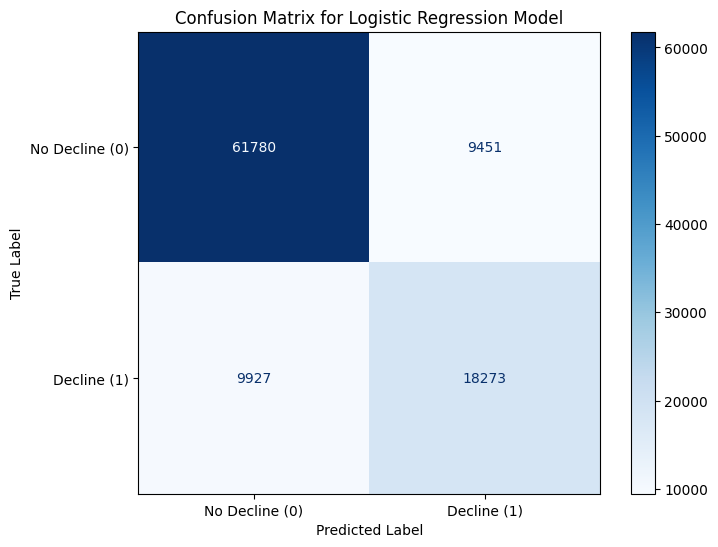

Interpretation:
  True Negatives (Correctly predicted no decline): 61780
  False Positives (Predicted decline, but no decline): 9451
  False Negatives (Predicted no decline, but decline occurred): 9927
  True Positives (Correctly predicted decline): 18273


In [89]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Decline (0)', 'Decline (1)'])
display_cm.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix for Logistic Regression Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False)
plt.show()

print("Interpretation:")
print(f"  True Negatives (Correctly predicted no decline): {cm[0, 0]}")
print(f"  False Positives (Predicted decline, but no decline): {cm[0, 1]})")
print(f"  False Negatives (Predicted no decline, but decline occurred): {cm[1, 0]})")
print(f"  True Positives (Correctly predicted decline): {cm[1, 1]})")

In [90]:
import numpy as np

# Get feature names after one-hot encoding and scaling
ohe = model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
categorical_feature_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = numerical_features + categorical_feature_names.tolist()

# Get the coefficients from the Logistic Regression model
coefficients = model.named_steps['classifier'].coef_[0]

# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients
})

# Sort by absolute coefficient value for easier interpretation
feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

display(feature_importance.head(20))

print("\nInterpretation of Coefficients:")
print("  Positive coefficients indicate that as the feature value increases, the log-odds of 'decline' (class 1) increases.")
print("  Negative coefficients indicate that as the feature value increases, the log-odds of 'decline' (class 1) decreases.")
print("  The magnitude of the coefficient indicates the strength of the relationship.")

,Feature,Coefficient,Abs_Coefficient
5,gsc_available,5.492915,5.492915
38,model_used_gemini-3-flash-preview,-1.319829,1.319829
35,provider_used_vexxskincare---openai,-1.114221,1.114221
42,model_used_None,-1.031354,1.031354
17,content_type_feedly article,-0.990816,0.990816
18,content_type_keyword article,-0.981371,0.981371
37,model_used_gemini-2.5-flash,-0.978648,0.978648
41,model_used_unknown,0.931489,0.931489
31,provider_used_gemini-generate-content,-0.856615,0.856615
19,competition_level_HIGH,-0.789836,0.789836



Interpretation of Coefficients:
  Positive coefficients indicate that as the feature value increases, the log-odds of 'decline' (class 1) increases.
  Negative coefficients indicate that as the feature value increases, the log-odds of 'decline' (class 1) decreases.
  The magnitude of the coefficient indicates the strength of the relationship.


## Self-check

Before you submit, confirm each line honestly:

- [X] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.